# API model showcase with PCA FE 46ch detrended

Loads the **FE artefacts the FastAPI service uses for `predict_fe46`**:

* `models/pca_fe_46ch.pkl` - 46-channel detrended PCA (k≈316, EV≈0.95)
* `models/scaler.pkl` - the kaggle 58-ch RobustScaler (predict_fe46 re-applies it)
* `data/raw/target_channels_fe.csv` - 46 channel names in canonical order
* `data/raw/target_channels.csv` - 58-channel order the scaler expects
* `models/fe_46ch_<ts>.json` - sidecar with the val-tuned threshold + post-filter

Runs `predict_fe46()` end-to-end on a small `test_api_fe*` slice and visualises the
result the way you'd want for a stakeholder walk-through - metrics, timeline,
event analysis, per-channel diagnostics, and a score distribution.

## 1 - Setup

In [15]:
%load_ext autoreload
%autoreload 2

import json, sys, time, pickle
from pathlib import Path
PROJECT_ROOT = Path('..').resolve()
for p in (PROJECT_ROOT / 'src', PROJECT_ROOT):
    sp = str(p)
    if sp not in sys.path:
        sys.path.insert(0, sp)

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Same imports as api/fast.py would use for the FE path
from sentinel.ml_logic.data      import load_target_channels, find_anomaly_segments
from sentinel.ml_logic.predictor import predict_fe46, predict_fe46_report
from sentinel.ml_logic.scorer    import clean_predictions
from sentinel.params             import (PROCESSED_DIR, MODELS_DIR, WINDOW_SIZE,
                                         ANOMALY_COLOR, NOMINAL_COLOR)

# Metrics + viz helpers
from sentinel.ml_logic.metrics import event_f05, corrected_event_f05, row_precision_recall
from sentinel.ml_logic.viz     import (
    plot_timeline, plot_event_analysis,
    plot_score_distribution, plot_confusion_and_channel_errors,
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
print('PROCESSED_DIR :', PROCESSED_DIR)
print('MODELS_DIR    :', MODELS_DIR)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PROCESSED_DIR : /Users/helena.schulz.ext/code/alexfederolf/sentinel/data/processed
MODELS_DIR    : /Users/helena.schulz.ext/code/alexfederolf/sentinel/models


## 2 - Load the FE artefacts and a demo slice

The same six objects the FE inference path needs:

* PCA model + 46-ch features (FE-specific)
* RobustScaler + 58-ch features (predict_fe46 re-scales, so we need the original 58 order)
* Threshold + post-filter config from the sidecar

Demo slice: **`test_api_fe.npy`** - raw 58-channel rows 14,175,000..14,475,000
of `train.parquet` (= rows 1.475M..1.775M relative to the kaggle internal test
split, 300k rows, 6 events, ~47.6% anomaly density). Rank-1 candidate from NB 23b.

In [16]:
with open(MODELS_DIR / 'pca_fe_46ch.pkl', 'rb') as f:
    pca_fe = pickle.load(f)
with open(MODELS_DIR / 'scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

features_full = load_target_channels()                                         # 58
features_fe   = list(pd.read_csv(PROJECT_ROOT / 'data' / 'raw' / 'target_channels_fe.csv')['target_channels'])  # 46

sidecar_path = sorted(MODELS_DIR.glob('fe_46ch_*.json'))[-1]
with open(sidecar_path) as f:
    sidecar = json.load(f)
threshold = float(sidecar['threshold'])
post_cfg  = sidecar['post_filter']

# FE demo slice = kaggle internal-test rows 14.2M..14.5M (300k rows, 6 events,
# ~46.9% anomaly density). Picked in NB 23b as a busy region representative of
# what the FE pipeline sees in production.
X_int = np.load(PROCESSED_DIR / 'test_api_fe.npy') # raw, 58ch
y_int = np.load(PROCESSED_DIR / 'y_test_api_fe.npy')

print(f'pca_fe       : {type(pca_fe).__name__}  k={pca_fe.n_components_}  '
      f'EV={pca_fe.explained_variance_ratio_.sum():.4f}')
print(f'scaler       : {type(scaler).__name__}')
print(f'features 58  : {len(features_full)}  →  {features_full[:2]} ... {features_full[-2:]}')
print(f'features 46  : {len(features_fe)}    (Tier A+B dropped)')
print(f'X_int        : {X_int.shape}   {X_int.dtype}')
print(f'y_int        : {y_int.shape}   anomaly rows: {int(y_int.sum()):,} ({y_int.mean():.2%})')
print(f'threshold    : {threshold:.6f}    (val ESA F0.5 = {sidecar["val_esa_f05"]:.4f})')
print(f'post-filter  : min_len={post_cfg["min_len"]}, max_gap={post_cfg["max_gap"]}')

pca_fe       : PCA  k=316  EV=0.9501
scaler       : RobustScaler
features 58  : 58  →  ['channel_12', 'channel_13'] ... ['channel_75', 'channel_76']
features 46  : 46    (Tier A+B dropped)
X_int        : (300000, 58)   float32
y_int        : (300000,)   anomaly rows: 142,876 (47.63%)
threshold    : 0.001970    (val ESA F0.5 = 0.8534)
post-filter  : min_len=100, max_gap=500


## 3 - Run the FE pipeline

`predict_fe46_report()` runs the exact recipe from `scripts/train_fe46.py` and
returns the full diagnostic dict (labels + row scores + window scores +
per-channel MSE + top-N channels per window) in one pass:

1. Scale raw 58ch with `models/scaler.pkl`.
2. Slice to the 46 FE channels.
3. Per-channel rolling-median input detrend (window 100k rows).
4. `score_report` (one-pass reconstruction) → `window_scores`,
   `per_channel_mse`, `window_channel_mse`, `window_top_channels`.
5. Score-level rolling-median detrend on `window_scores`, broadcast to rows.
6. `row_scores > threshold` → raw labels.
7. `clean_predictions(min_len, max_gap)` → FE post-filtered labels.

We pass `post_filter=False` to keep the raw threshold output (the score plots
need it), then apply `clean_predictions` ourselves for side-by-side comparison.

The lean operational path is `predict_fe46()` — same recipe, returns only
`{id, is_anomaly}`. That's what FastAPI's `/timeline` and `POST /predict` use.
Use this analytical wrapper when you also need the diagnostics.

In [17]:
t0 = time.time()
rep = predict_fe46_report(
    X_raw         = X_int,
    model         = pca_fe,
    scaler        = scaler,
    features_full = features_full,
    features_fe   = features_fe,
    threshold     = threshold,
    post_filter   = False,
    n_top_channels= 6,
)
print(f'predict_fe46_report (raw) : {time.time()-t0:.2f}s   '
      f'flag {rep["labels"].mean():.2%}  blocks {len(find_anomaly_segments(rep["labels"]))}')

row_scores          = rep['row_scores']
window_scores       = rep['window_scores']
window_channel_mse  = rep['window_channel_mse']
window_top_channels = rep['window_top_channels']
per_channel_mse     = rep['per_channel_mse']
labels_raw          = rep['labels']

labels_clean = clean_predictions(
    labels_raw,
    min_len=post_cfg['min_len'],
    max_gap=post_cfg['max_gap'],
)
print(f'predict_fe46_report (post-filter): flag {labels_clean.mean():.2%}  '
      f'blocks {len(find_anomaly_segments(labels_clean))}')

print(f'\nrow_scores       : {row_scores.shape}   range [{row_scores.min():.4f}, {row_scores.max():.4f}]')
print(f'per_channel_mse  : {per_channel_mse.shape}')
print(f'top-6 indices    : {window_top_channels.shape}')

predict_fe46_report (raw) : 1.72s   flag 29.70%  blocks 15
predict_fe46_report (post-filter): flag 30.03%  blocks 7

row_scores       : (300000,)   range [-0.0118, 1.6491]
per_channel_mse  : (46,)
top-6 indices    : (3000, 6)


In [18]:
# Balanced preview: 5 rows around the first nominal→anomaly transition,
# 5 around the first anomaly→nominal transition. Shows what /predict returns
# both on quiet and noisy rows in the same table.
diff = np.diff(y_int.astype(int), prepend=y_int[0])
on_idx  = int(np.argmax(diff ==  1)) if (diff ==  1).any() else len(y_int)//4
off_idx = int(np.argmax(diff == -1)) if (diff == -1).any() else 3*len(y_int)//4
sample = sorted(set(list(range(max(0, on_idx-2),  on_idx+3)) +
                    list(range(max(0, off_idx-2), off_idx+3))))

preview = pd.DataFrame({
    'id'        : np.array(sample, dtype=np.int64),
    'is_anomaly': labels_raw[sample],
    'score'     : row_scores[sample].round(5),
    'cleaned'   : labels_clean[sample],
    'gt_label'  : y_int[sample],
})
print(f'Preview around transitions  (nominal→anomaly @ row {on_idx:,}, '
      f'anomaly→nominal @ row {off_idx:,})')
print(preview.to_string(index=False))

Preview around transitions  (nominal→anomaly @ row 22,874, anomaly→nominal @ row 91,215)
   id  is_anomaly   score  cleaned  gt_label
22872           1 0.00971        1         0
22873           1 0.00971        1         0
22874           1 0.00971        1         1
22875           1 0.00971        1         1
22876           1 0.00971        1         1
91213           1 0.02421        1         1
91214           1 0.02421        1         1
91215           1 0.02421        1         0
91216           1 0.02421        1         0
91217           1 0.02421        1         0


## 4 - Metrics

Threshold is fixed at `sidecar['threshold']` (the val-tuned value baked into the
FE artefact); we don't re-tune here. We compute the standard suite (event-wise,
ESA-corrected, row-level) on the **post-filtered** labels — that's the FE-blessed
output.

In [19]:
labels = labels_clean   # FE-blessed output
ef  = event_f05(y_int, labels)
esa = corrected_event_f05(y_int, labels)
rw  = row_precision_recall(y_int, labels)
n_ev_total = int(ef['tp_events'] + ef['fn_events'])
n_ev_hit   = int(ef['tp_events'])

m = {
    'event F0.5'      : ef['f_score'],
    'event precision' : ef['precision'],
    'event recall'    : ef['recall'],
    'ESA F0.5'        : esa['f_score'],
    'ESA Pr_ew'       : esa['precision'],
    'ESA TNR'         : esa['tnr'],
    'row F1'          : rw['f1'],
    'row precision'   : rw['precision'],
    'row recall'      : rw['recall'],
    'flag rate'       : float(labels.mean()),
    'events hit'      : f'{n_ev_hit}/{n_ev_total} ({n_ev_hit/max(n_ev_total,1):.1%})',
    'fp pred events'  : int(ef['fp_pred_events']),
}
order = ['ESA F0.5','ESA Pr_ew','ESA TNR',
         'event F0.5','event precision','event recall',
         'row F1','row precision','row recall',
         'flag rate','events hit','fp pred events']
df_m = pd.DataFrame({'Metric': order, 'Value': [m[k] for k in order]})
def _fmt(v):
    if isinstance(v,(int,np.integer)): return str(int(v))
    if isinstance(v,float): return f'{v:.4f}'
    return str(v)
df_m['Value'] = df_m['Value'].map(_fmt)

print(f'FE 46ch on demo slice  ·  threshold = {threshold:.6f}  ·  post-filter ON')
print(df_m.to_string(index=False))

FE 46ch on demo slice  ·  threshold = 0.001970  ·  post-filter ON
         Metric       Value
       ESA F0.5      0.6647
      ESA Pr_ew      0.6327
        ESA TNR      0.7593
     event F0.5      0.8333
event precision      0.8333
   event recall      0.8333
         row F1      0.4487
  row precision      0.5802
     row recall      0.3659
      flag rate      0.3003
     events hit 5/6 (83.3%)
 fp pred events           1


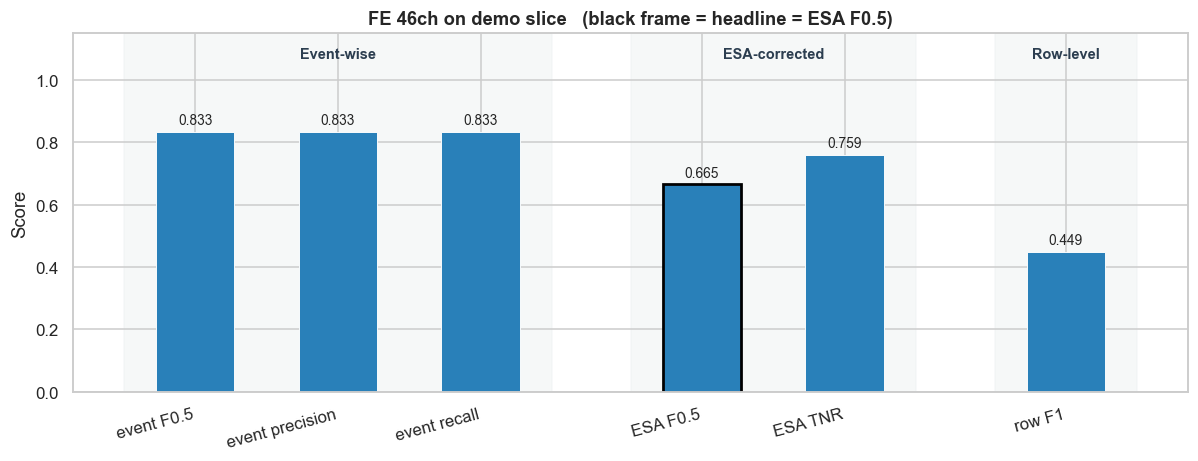

In [20]:
BAR_GROUPS = [
    ('Event-wise',    ['event F0.5', 'event precision', 'event recall']),
    ('ESA-corrected', ['ESA F0.5', 'ESA TNR']),
    ('Row-level',     ['row F1']),
]
TUNE_LABEL = 'ESA F0.5'

fig, ax = plt.subplots(figsize=(11, 4.3))
w, gap = 0.55, 0.55
xs, xticks, xlabels, band_edges = [], [], [], []
cursor = 0.0
for gname, group_labels in BAR_GROUPS:
    grp_start = cursor
    for lbl in group_labels:
        xs.append(cursor); xticks.append(cursor); xlabels.append(lbl)
        cursor += 1.0
    band_edges.append((gname, grp_start - 0.5, cursor - 0.5))
    cursor += gap

xs   = np.asarray(xs)
vals = [m[l] for l in xlabels]
edges = ['black' if l == TUNE_LABEL else 'white' for l in xlabels]
lws   = [1.8     if l == TUNE_LABEL else 0.6     for l in xlabels]
b = ax.bar(xs, vals, w, color=NOMINAL_COLOR, edgecolor=edges, linewidth=lws)
ax.bar_label(b, fmt='%.3f', fontsize=9, padding=3)

for gname, xlo, xhi in band_edges:
    ax.axvspan(xlo, xhi, color='#ecf0f1', alpha=0.45, zorder=0)
    ax.text((xlo+xhi)/2, 1.06, gname, ha='center', va='bottom',
            fontsize=9.5, fontweight='bold', color='#2c3e50')

ax.set_xticks(xticks); ax.set_xticklabels(xlabels, rotation=15, ha='right')
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title(f'FE 46ch on demo slice   (black frame = headline = {TUNE_LABEL})', fontweight='bold')
fig.tight_layout(); plt.show()

## 5 - Timeline

Top: per-row detrended reconstruction MSE with the FE threshold (red dashed)
and true-anomaly bands shaded behind it. Bottom: predicted-event ribbon split
into TPs (green) vs FPs (lavender). `log_y` spreads small events that would
otherwise be flattened by the largest spike.

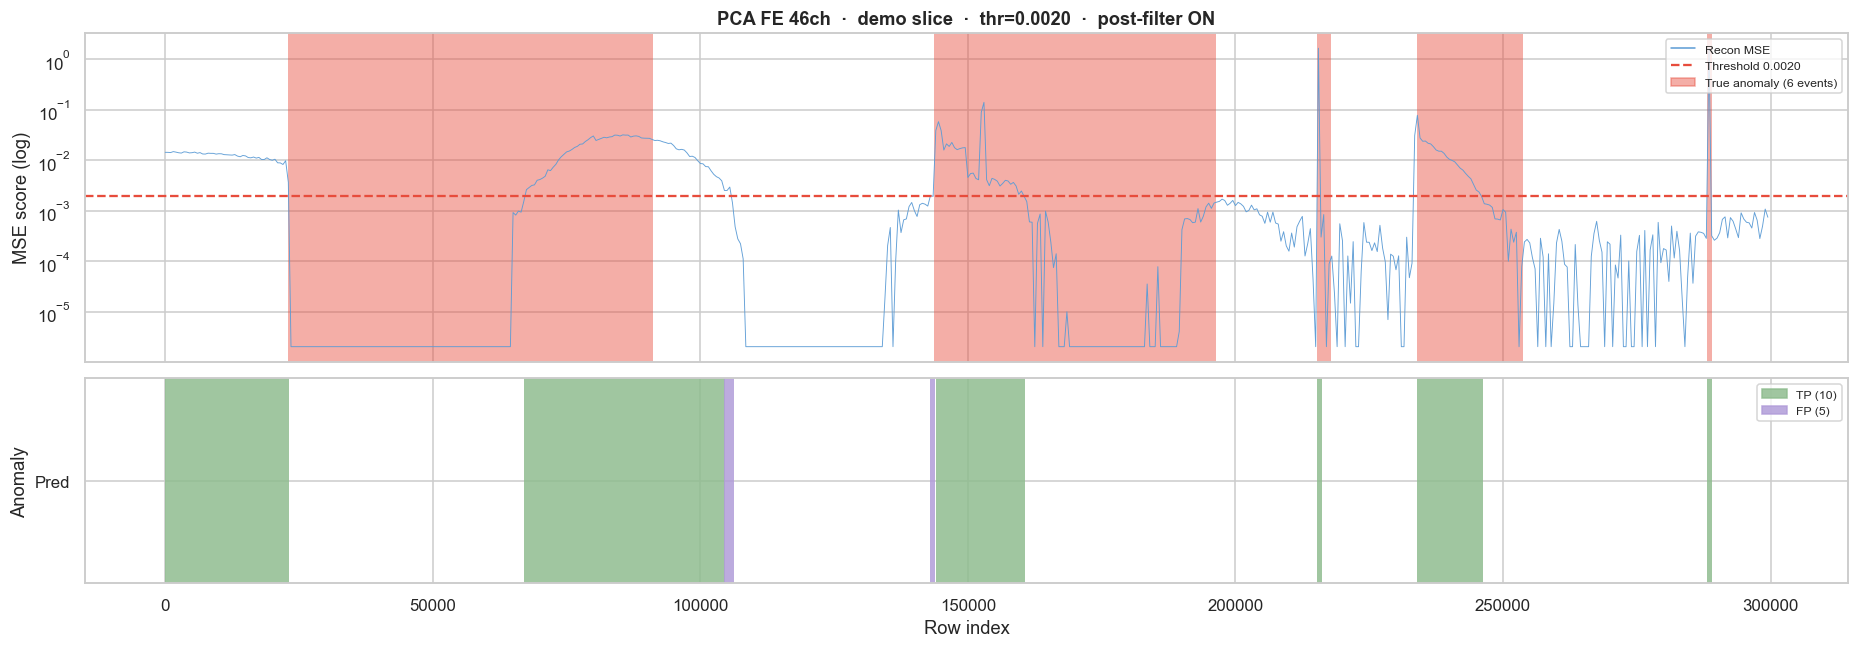

In [21]:
fig = plot_timeline(
    scores=row_scores, y_true=y_int, threshold=threshold,
    title=f'PCA FE 46ch  ·  demo slice  ·  thr={threshold:.4f}  ·  post-filter ON',
    log_y=True,
)
plt.show()

## 6 - Event analysis

Three-panel diagnostic per event:
1. Detected vs missed counts.
2. Coverage (fraction of event rows flagged) vs event length.
3. Hit-rate distribution.

Followed by the table of missed events (start / end / length) so it's clear
which segments the FE model can't catch.

Missed events:
 start    end  length
215836 217821    1986


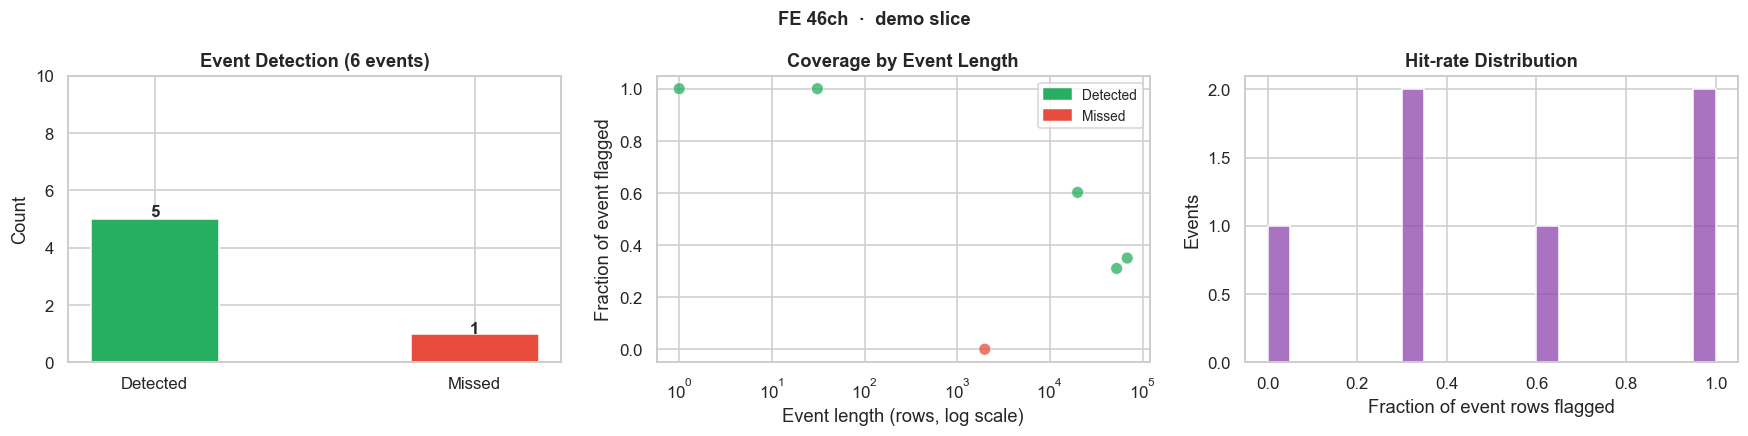

In [22]:
_ = plot_event_analysis(y_int, labels, title='FE 46ch  ·  demo slice')
plt.show()

## 7 - Score distribution & row-level diagnostics

* **Score histogram by class (window-level)** - one score per non-overlapping
  100-row window, labelled anomalous if it contains any anomaly row. Plotting
  at window level (not row level) is correct because the FE pipeline scores at
  the window granularity; row scores are window MSE broadcast.
* **Confusion matrix + per-channel MSE** - row-level confusion plus the top
  channels by mean reconstruction error. Channels driving the score surface here.
  Channel indices map to the 46 FE channels (`features_fe`).

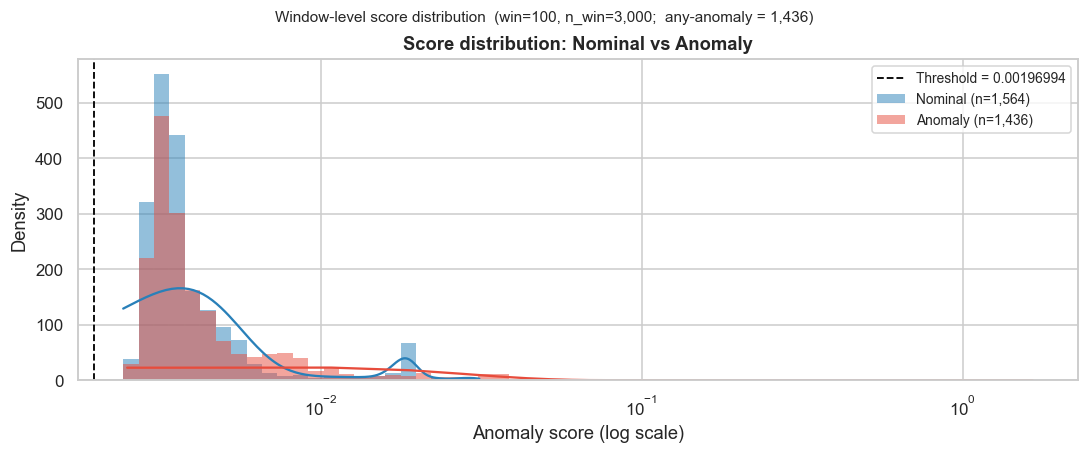

In [23]:
from sentinel.params import WINDOW_SIZE as WIN

n_win     = len(window_scores)
win_label = y_int[:n_win * WIN].reshape(n_win, WIN).any(axis=1).astype('int8')

fig = plot_score_distribution(window_scores, win_label, threshold=threshold)
fig.suptitle(
    f"Window-level score distribution  (win={WIN}, "
    f"n_win={n_win:,};  any-anomaly = {int(win_label.sum()):,})",
    y=1.02, fontsize=10,
)
plt.show()

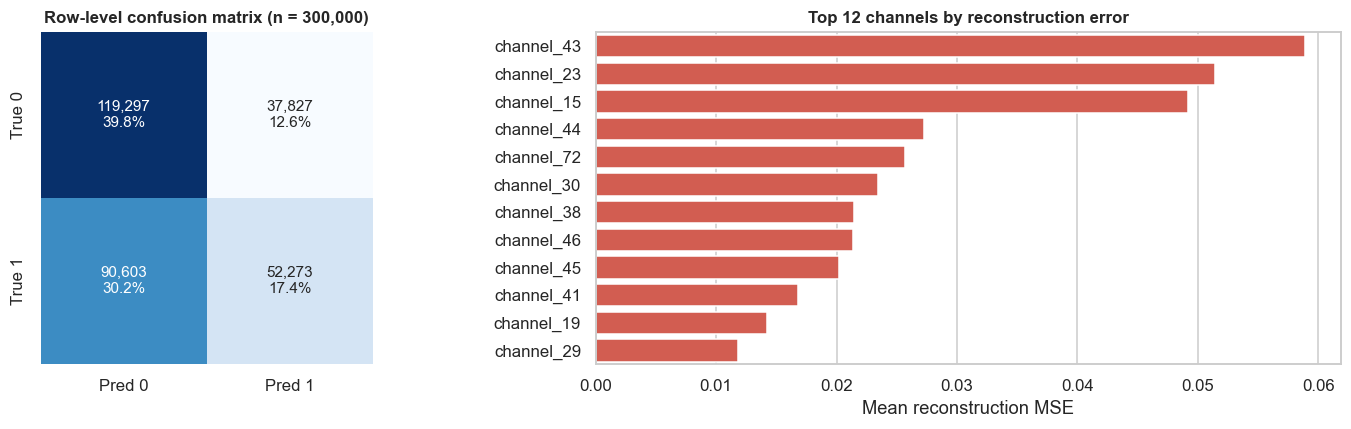

In [24]:
fig = plot_confusion_and_channel_errors(
    y_true=y_int, y_pred=labels,
    per_channel_mse=per_channel_mse,
    channel_names=features_fe,
    top_k=12,
)
plt.show()

## 8 - Top-N channel frequency

`score_report(n_top_channels=6)` returns, for every window, the indices of the
6 channels (within the 46 FE channels) with the largest reconstruction error.
Counting how often each channel shows up in that top-6 tells us which channels
are the *primary suspects* across the slice - useful for explaining a flagged
window to an operator (which channel triggered it).

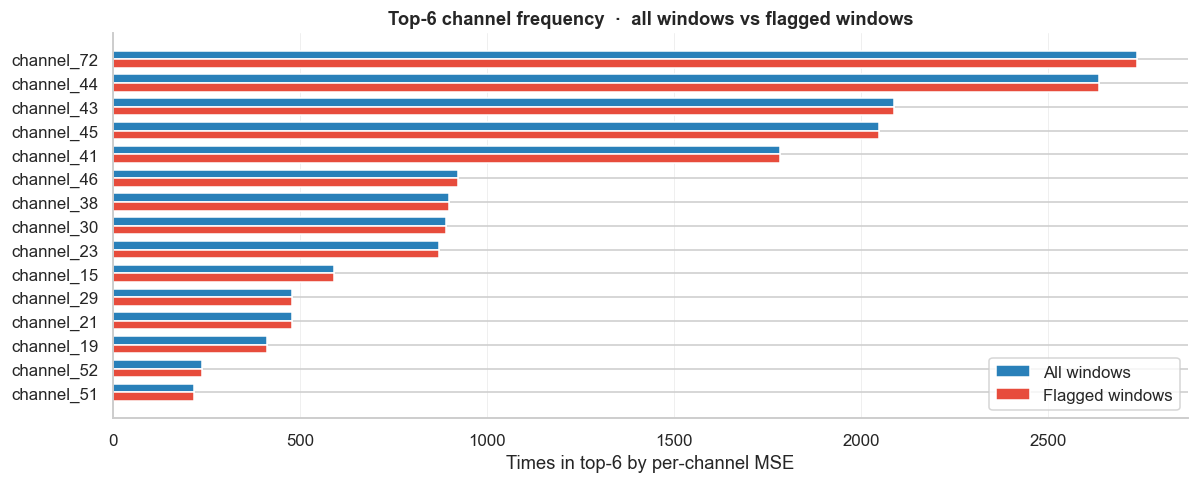


Total windows: 3,000   ·   flagged: 3,000 (100.00%)


In [25]:
win_pred = (window_scores > threshold).astype(np.int8)

freq_all     = np.bincount(window_top_channels.ravel(), minlength=len(features_fe))
freq_flagged = (np.bincount(window_top_channels[win_pred == 1].ravel(),
                            minlength=len(features_fe))
                if win_pred.any() else np.zeros(len(features_fe), dtype=int))

df_top = pd.DataFrame({
    'channel'   : features_fe,
    'all_wins'  : freq_all,
    'flagged'   : freq_flagged,
}).sort_values('flagged', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 4.5))
y = np.arange(len(df_top))
ax.barh(y - 0.18, df_top['all_wins'], 0.36, color=NOMINAL_COLOR, label='All windows', edgecolor='white')
ax.barh(y + 0.18, df_top['flagged'],  0.36, color=ANOMALY_COLOR, label='Flagged windows', edgecolor='white')
ax.set_yticks(y); ax.set_yticklabels(df_top['channel'])
ax.invert_yaxis()
ax.set_xlabel('Times in top-6 by per-channel MSE')
ax.set_title('Top-6 channel frequency  ·  all windows vs flagged windows', fontweight='bold')
ax.legend(loc='lower right'); ax.grid(True, axis='x', color='#eeeeee', lw=0.6, zorder=0)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
fig.tight_layout(); plt.show()

print(f'\nTotal windows: {len(window_scores):,}   ·   flagged: {int(win_pred.sum()):,} ({win_pred.mean():.2%})')

## 9 - Top channel signal timelines

Raw signal for the channels with the highest reconstruction error (top 6 by
per-channel MSE). Ground-truth anomaly windows are shaded in red so you can
see directly which channels misbehave during real events.

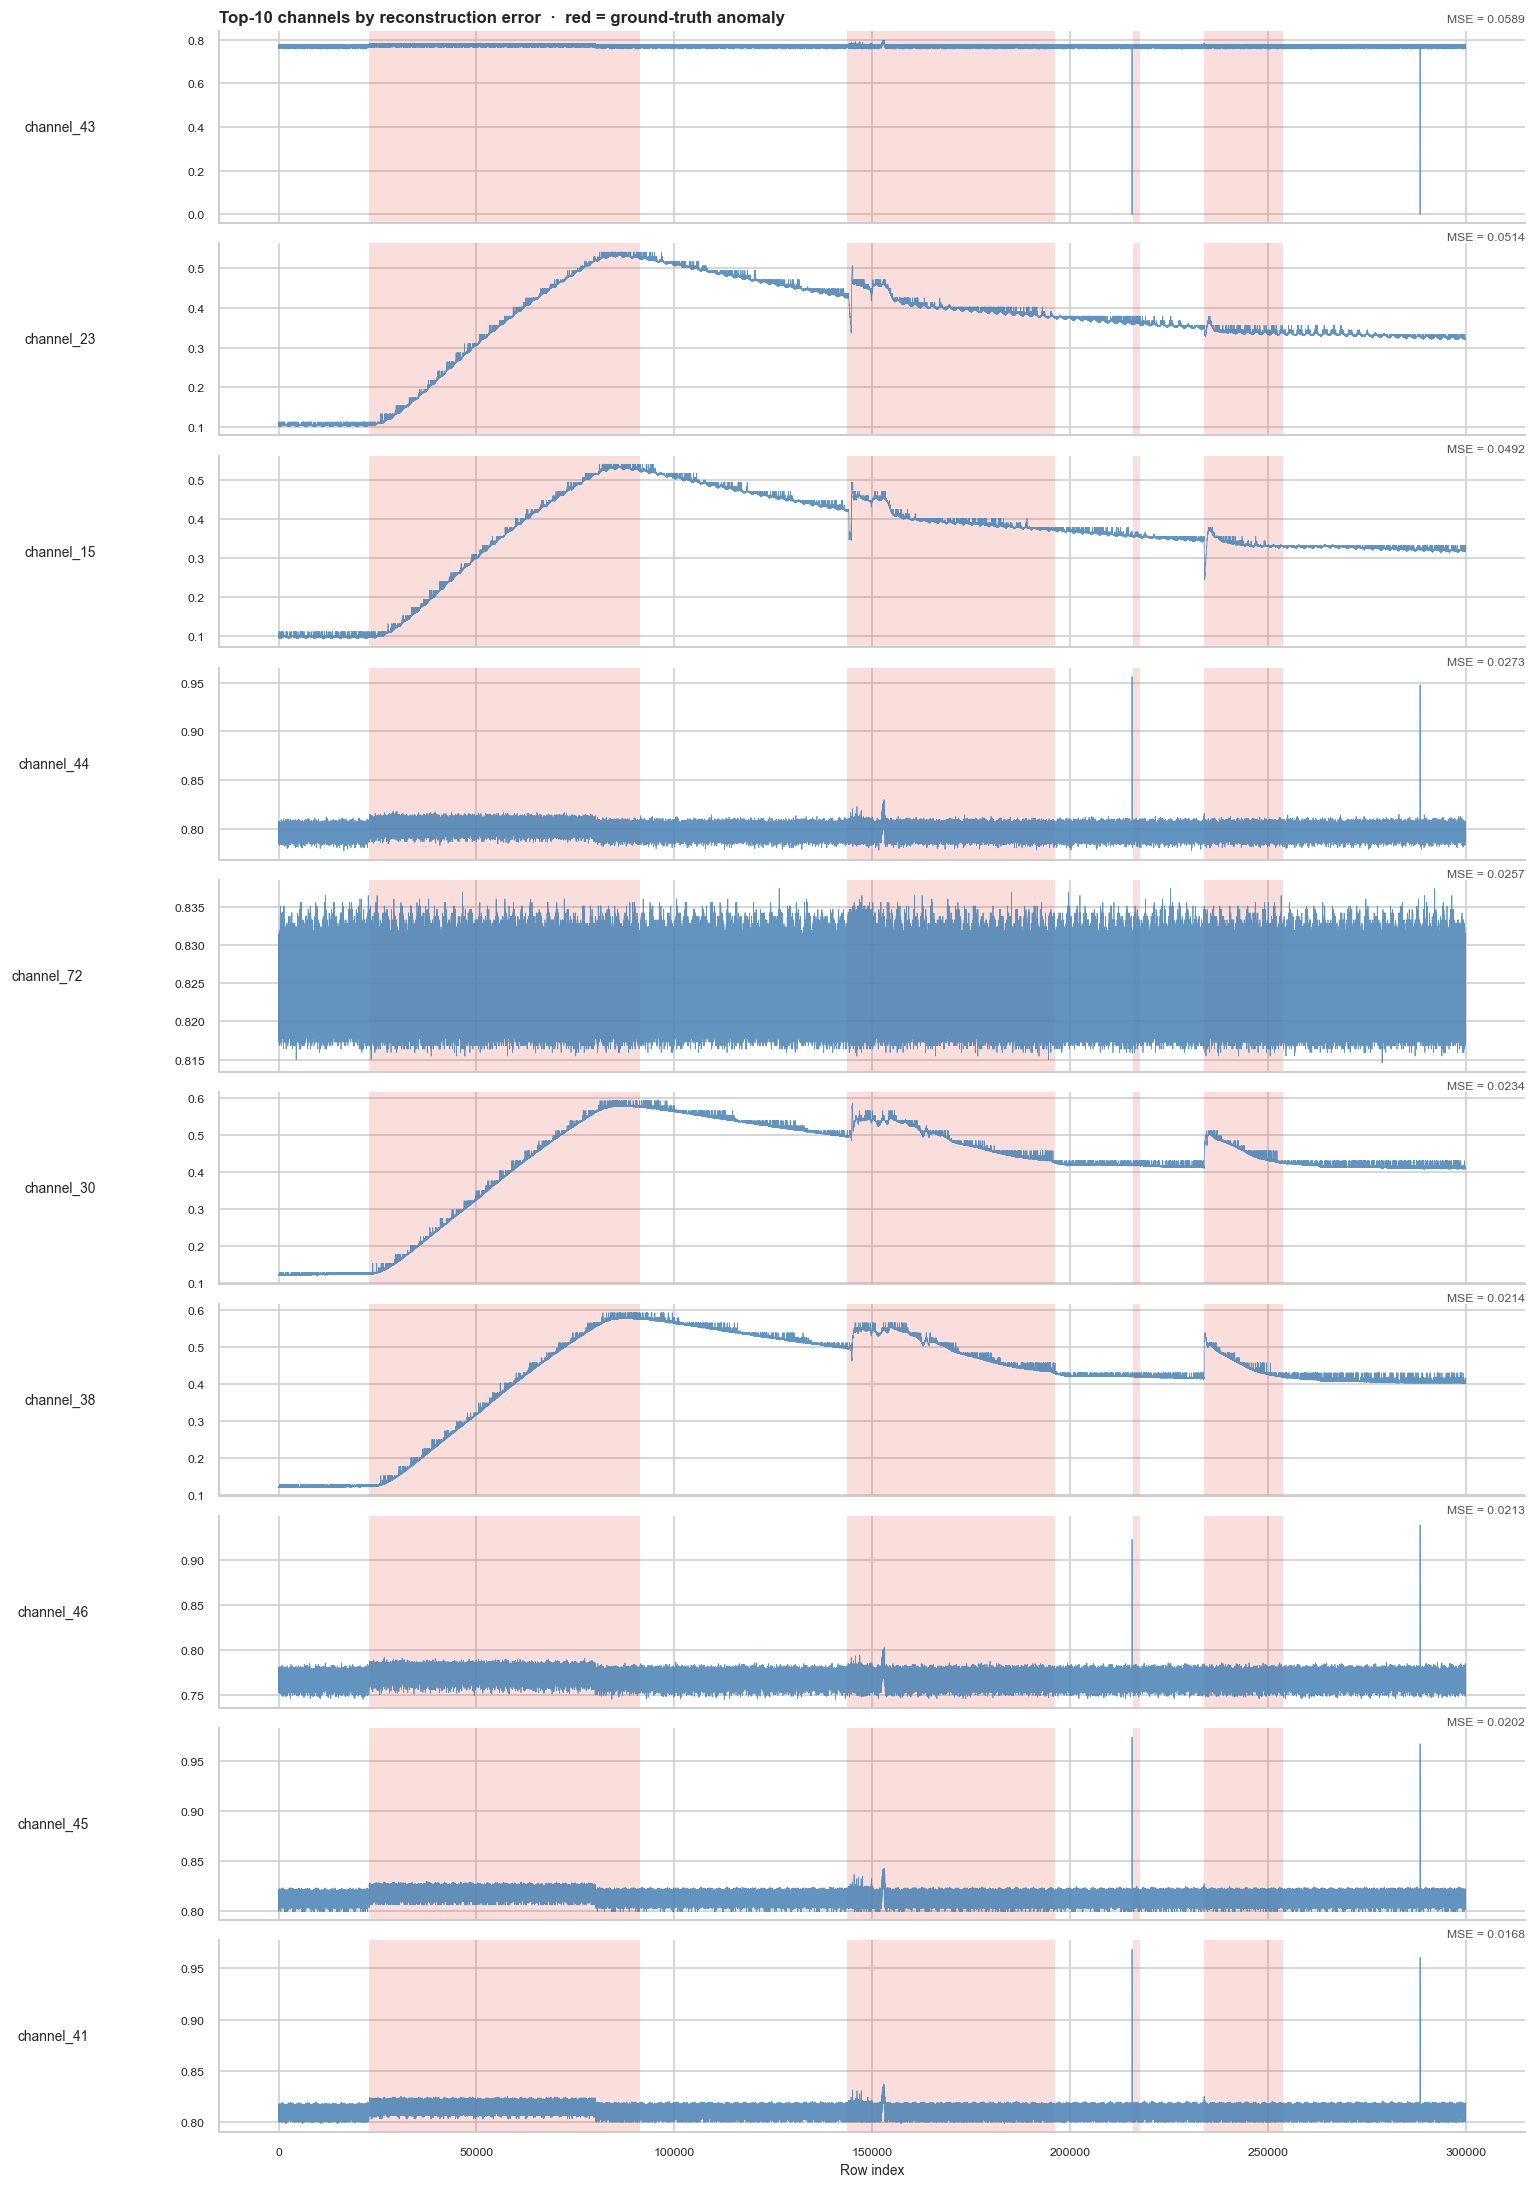

In [26]:
TOP_N = 10 # number of channels to show

# ── pick top channels by overall per-channel MSE ──────────────────────────────
top_idx  = np.argsort(per_channel_mse)[::-1][:TOP_N]
top_chs  = [features_fe[i] for i in top_idx]

# ── map FE channel names → column indices in the raw 58-ch X_int ──────────────
col_idx  = [features_full.index(ch) for ch in top_chs]

# ── find ground-truth anomaly segments for shading ────────────────────────────
segs = find_anomaly_segments(y_int)   # list of {start, end, length} dicts

x = np.arange(len(X_int))

fig, axes = plt.subplots(TOP_N, 1, figsize=(14, TOP_N * 2.0), sharex=True)
for ax, ch, ci, mse in zip(axes, top_chs, col_idx, per_channel_mse[top_idx]):
    signal = X_int[:, ci].astype(np.float32)
    ax.plot(x, signal, lw=0.5, color='steelblue', alpha=0.85)

    # shade ground-truth anomaly windows
    for seg in segs:
        ax.axvspan(seg['start'], seg['end'], color=ANOMALY_COLOR, alpha=0.18, linewidth=0)

    ax.set_ylabel(ch, fontsize=9, rotation=0, ha='right', va='center', labelpad=60)
    ax.set_title(f'MSE = {mse:.4f}', fontsize=8, loc='right', pad=2, color='#555')
    ax.tick_params(labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('Row index', fontsize=9)
axes[0].set_title(
    f'Top-{TOP_N} channels by reconstruction error  ·  red = ground-truth anomaly',
    fontsize=11, fontweight='bold', loc='left',
)
fig.tight_layout(h_pad=0.6)
plt.show()